# Explore here

In [59]:
# Your code here

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error,r2_score
from scipy.stats import randint
from pickle import dump




In [65]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [70]:
Direccion_guardado = "/workspaces/Marcos-J-Gomes_RandomForest/data/processed"

total_data= pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv")
X_train_sel_CON_outliers= pd.read_csv(f"{Direccion_guardado}/X_train_sel_CON_outliers_clean.csv")
X_test_sel_CON_outliers= pd.read_csv(f"{Direccion_guardado}/X_test_sel_CON_outliers_clean.csv")
X_train_sel_SIN_outliers=pd.read_csv(f"{Direccion_guardado}/X_train_sel_SIN_outliers_clean.csv")
X_test_sel_SIN_outliers=pd.read_csv(f"{Direccion_guardado}/X_test_sel_SIN_outliers_clean.csv")
y_train = pd.read_excel(f"{Direccion_guardado}/y_train.xlsx")
y_test  = pd.read_excel(f"{Direccion_guardado}/y_test.xlsx")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

target= "Outcome"

In [79]:
datasets = {
    "CON_outliers": (X_train_sel_CON_outliers.drop(target, axis = 1), X_test_sel_CON_outliers.drop(target, axis = 1)),
    "SIN_outliers": (X_train_sel_SIN_outliers.drop(target, axis = 1), X_test_sel_SIN_outliers.drop(target, axis = 1))
}

Resultados = {}

for dataset_, (X_train, X_test) in datasets.items():
    model = RandomForestClassifier(n_estimators = 50, random_state= 17)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    Resultados[dataset_] = {
        "Model" : model,
        "Accuracy" : accuracy_score(y_test, y_pred),
    }

mejor_dataset = max(Resultados, key=lambda x: Resultados[x]["Accuracy"])
mejor_Acurracy = Resultados[mejor_dataset]["Accuracy"]
mejor_modelo = Resultados[mejor_dataset]["Model"]

print("Resultados por dataset:")
for k, v in Resultados.items():
    print(f"{k:25s} -> Acurracy: {v["Accuracy"]:.5f}")

Resultados por dataset:
CON_outliers              -> Acurracy: 0.79221
SIN_outliers              -> Acurracy: 0.79221


Notamos un aumento con respecto al modelo optimizado del "Arbol de decision" del proyecto anterior, cuyos datos eran:
- 0.7792207792207793

Lo cual resulta en un aumento de nuestro acurracy de 0.01299

In [72]:
dump(mejor_modelo, open("../models/random_forest_regressor_n_estimators-50_RS-17.sav", "wb"))

Pruebas

In [86]:
Resultados_2 = {
    "CON_outliers": [],
    "SIN_outliers": []
}
n_estimators = [50, 100, 200, 300, 500]
learning_rates = [0.001,0.01,0.1,1] 
accuracies = []

for dataset_, (X_train, X_test) in datasets.items():
    for n in n_estimators:
        model = RandomForestClassifier(n_estimators = n, random_state= 17)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        
        Resultados_2[dataset_].append({
            "n_estimators": n,
            "accuracy": acc,
            "model": model
        })

mejor_global = None
mejor_dataset = None

for dataset_, results in Resultados_2.items():
    for r in results:
        if mejor_global is None or r["accuracy"] > mejor_global["accuracy"]:
            mejor_global = r
            mejor_dataset = dataset_

print("Mejor resultado global:")
print(f"Dataset: {mejor_dataset}")
print(f"n_estimators: {mejor_global['n_estimators']}")
print(f"Accuracy: {mejor_global['accuracy']:.5f}")

Mejor resultado global:
Dataset: CON_outliers
n_estimators: 300
Accuracy: 0.81169


Notamos que al subir el valor de "n_estimators" nuestro Acurracy aumenta hasta cierto punto, por lo que para alcanzar un modelo con mayor precision deberiamos aumentarlo en la medida de lo posible

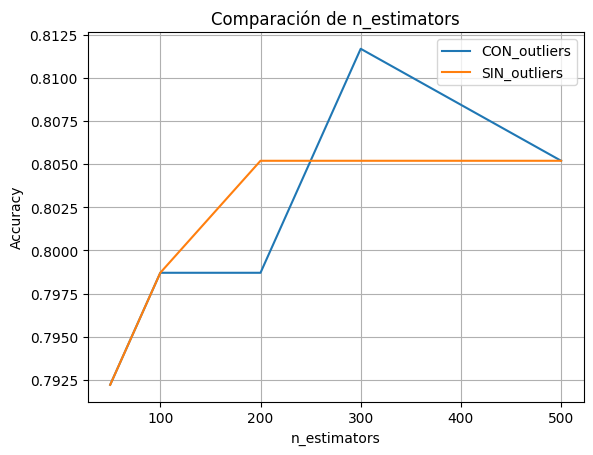

In [92]:
plt.figure()

for dataset_, results in Resultados_2.items():
    n_estimators = [r["n_estimators"] for r in results]
    accuracies = [r["accuracy"] for r in results]

    sns.lineplot(x= n_estimators, y= accuracies, label=dataset_)

plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Comparación de n_estimators")
plt.legend()
plt.grid(True)
plt.show()

Al revisar la grafica podemos notar como nuestro comentario anterios pierde validez, ya que nuestros datasets tienen puntos de infleccion donde "Sin Outliers" parece aplanarce luego de los 200 estimators mientras que "Con Outliers" tiene un pico en los 300 estimators pero luego va en bajada